# Descripción del Proyecto

Al operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos.

### Servicios de Interconnect

Interconnect proporciona principalmente dos tipos de servicios:

1. Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea.
2. Internet. La red se puede configurar a través de una línea telefónica (DSL, *línea de abonado digital*) o a través de un cable de fibra óptica.

Algunos otros servicios que ofrece la empresa incluyen:

- Seguridad en Internet: software antivirus (*ProtecciónDeDispositivo*) y un bloqueador de sitios web maliciosos (*SeguridadEnLínea*).
- Una línea de soporte técnico (*SoporteTécnico*).
- Almacenamiento de archivos en la nube y backup de datos (*BackupOnline*).
- Streaming de TV (*StreamingTV*) y directorio de películas (*StreamingPelículas*)

La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción.

### Descripción de los datos

Los datos consisten en archivos obtenidos de diferentes fuentes:

- `contract.csv` — información del contrato;
- `personal.csv` — datos personales del cliente;
- `internet.csv` — información sobre los servicios de Internet;
- `phone.csv` — información sobre los servicios telefónicos.

En cada archivo, la columna `customerID` (ID de cliente) contiene un código único asignado a cada cliente. La información del contrato es válida a partir del 1 de febrero de 2020.

### Datos

[final_provider.zip](https://s3-us-west-2.amazonaws.com/secure.notion-static.com/94210e31-fd3d-451b-a350-4a8476756413/final_provider.zip)

Los datos también se encuentran en la plataforma, en la carpeta `/datasets/final_provider/`.

# Plan de Trabajo

Para este proyecto seguiremos los siguientes pasos:

1. Inicializacion de librerias e importar df's.
2. Vista previa y pre procesamiento de los datos, ver si hay que imputar, limpiar o dropear datos.
3. Adaptar las características de las columnas para las necesidades de nuestro modelo.
4. Entrenar distintos modelos para despues poder compararlos, cada modelo se usara un gridsearch para ver la optimizacion de hiperparametros. Tomar como metrica el valor AUC-ROC.
5. Comparar los resultados y escoger un modelo.

# Inicialización

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.metrics as metrics
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, NearMiss
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from collections import Counter

Tenemos 4 archivos, estos son contract, internet, personal y phone. Cada uno tiene un ID unico asignado a cada cliente.

In [31]:
pd.options.display.max_columns = None

contract_df = pd.read_csv('final_provider/contract.csv')
internet_df = pd.read_csv('final_provider/internet.csv')
personal_df = pd.read_csv('final_provider/personal.csv')
phone_df = pd.read_csv('final_provider/phone.csv')

In [32]:
df_paths = [
    ("Contract", contract_df),
    ("Internet", internet_df),
    ("Personal", personal_df),
    ("Phone", phone_df)
]

for name, df in df_paths:
    print(f"{name}: {df.shape}")

Contract: (7043, 8)
Internet: (5517, 8)
Personal: (7043, 5)
Phone: (6361, 2)


Podemos ver que tanto el df ```Contract``` como el de ```Personal``` comparten la misma cantidad de clientes, por otra parte el df de internet y el de phone no. Esto podria decirme que no todos los clientes tienen paquete de internet o paquete de telefono.

### Información de DF's

In [33]:
for name, df in df_paths:
    print(f'{name}\n')
    display(df)
    print(df.info())
    print()

Contract



,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.5
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.9
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
None

Internet



,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...
5512,6840-RESVB,DSL,Yes,No,Yes,Yes,Yes,Yes
5513,2234-XADUH,Fiber optic,No,Yes,Yes,No,Yes,Yes
5514,4801-JZAZL,DSL,Yes,No,No,No,No,No
5515,8361-LTMKD,Fiber optic,No,No,No,No,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
None

Personal



,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
None

Phone



,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
...,...,...
6356,2569-WGERO,No
6357,6840-RESVB,Yes
6358,2234-XADUH,Yes
6359,8361-LTMKD,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
None



Ni un solo df tiene datos ausentes, pero...

En el df ```Contract``` podemos:
- Cambiar la columna PaperlessBilling a booleano (1,0)
- La columna de TotalCharges pasarla de object a float
- Pasar a dates las columnas de start y end date.

En el df ```Internet``` podemos:
- Pasar todas las columnas a tipo booleano, incluse la de InternetService en lugar de tener categoria DSL o FibreOptic podemos poner DSL -> 1 y Fibre -> 0

En el df ```Personal``` podemos:
- Todas las columnas podemos pasarlas a el tipo booleano, ejemplo gender hombre -> 1, mujer -> 0.

En el df ```Phone``` podemos:
- Pasar la columna a bool.

Antes de realizar cualquier tipo de limpieza en estos datos creo que es necesario juntar nuestras tablas con join en ```CustomerID```, esto principalmente a que los clientes que tienen internet pero no tienen telefono o viceversa llenaran de nans ciertas columnas.

# Preprocesamiento de Datos

Empezaremos uniendo todas mis tablas.

In [34]:
df = contract_df.merge(internet_df, how='left', on='customerID')
df = df.merge(personal_df, how='left', on='customerID')
df = df.merge(phone_df, how='left', on='customerID')

df.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Female,0,Yes,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,DSL,Yes,No,Yes,No,No,No,Male,0,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,DSL,Yes,Yes,No,No,No,No,Male,0,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,DSL,Yes,No,Yes,Yes,No,No,Male,0,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,No,No,No,No,No,No,Female,0,No,No,No


In [35]:
# Creamos nuestra columna Target
df['target'] = np.where(df['EndDate'] == 'No', 0, 1)

Debido a que la columna de ```TotalCharges``` es del tipo object, procederemos a ver que podria ser el problema.

In [36]:
df['TotalCharges'].value_counts()

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [37]:
df[df['TotalCharges'] == ' ']

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,MultipleLines,target
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,,DSL,Yes,No,Yes,Yes,Yes,No,Female,0,Yes,Yes,NaN,0
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,0,No,Yes,No,0
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,,DSL,Yes,Yes,Yes,No,Yes,Yes,Female,0,Yes,Yes,No,0
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,Yes,0
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,,DSL,Yes,Yes,Yes,Yes,Yes,No,Female,0,Yes,Yes,NaN,0
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,No,0
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,Yes,0
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,0,Yes,Yes,No,0
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,No,0
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,,DSL,No,Yes,Yes,Yes,Yes,No,Female,0,Yes,Yes,Yes,0


Encontramos que hay 11 valores con un valor de ```' '```, en este caso vamos a hacerles drop, adicionalmente estos son clientes relativamente nuevos entonces no afectara mucho al modelo.

In [38]:
# Eliminamos las filas con valores ausentes
df = df[df['TotalCharges'] != ' '].copy()

# Pasamos el nuestra columna a tipo float
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [39]:
# Columnas para pasar a bool
bool_columns = ['PaperlessBilling', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Partner', 'Dependents', 'MultipleLines']

# Asignar 0 al No y 1 al Yes
df[bool_columns] = df[bool_columns].fillna('No')
df[bool_columns] = df[bool_columns].apply(lambda col: col.map({'Yes': 1, 'No': 0}).astype('Int64'))

Agregamos el fillna en No debido a que implicitamente estas columnas son un No, los clientes que manejan internet no tiene multiples lineas, y lo mismo, clientes que no tienen internet no tienen servicios exclusivos.

In [40]:
# Buscamos duplicados
df['customerID'].duplicated().sum()

0

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   BeginDate         7032 non-null   object 
 2   EndDate           7032 non-null   object 
 3   Type              7032 non-null   object 
 4   PaperlessBilling  7032 non-null   Int64  
 5   PaymentMethod     7032 non-null   object 
 6   MonthlyCharges    7032 non-null   float64
 7   TotalCharges      7032 non-null   float64
 8   InternetService   5512 non-null   object 
 9   OnlineSecurity    7032 non-null   Int64  
 10  OnlineBackup      7032 non-null   Int64  
 11  DeviceProtection  7032 non-null   Int64  
 12  TechSupport       7032 non-null   Int64  
 13  StreamingTV       7032 non-null   Int64  
 14  StreamingMovies   7032 non-null   Int64  
 15  gender            7032 non-null   object 
 16  SeniorCitizen     7032 non-null   int64  
 17  

### Exploramos columnas categoricas, numericas y booleanas

In [42]:
# Veamos las categoricas
for column in ['Type', 'PaymentMethod','InternetService', 'gender']:
    print(f'{column}: {df[column].unique()}\n')

Type: ['Month-to-month' 'One year' 'Two year']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

InternetService: ['DSL' 'Fiber optic' nan]

gender: ['Female' 'Male']



In [43]:
# Relleno valores con None
df['InternetService'] = df['InternetService'].fillna('None')

In [44]:
df[['MonthlyCharges', 'TotalCharges']].describe()

,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000
mean,64.798208,2283.300441
std,30.085974,2266.771362
min,18.250000,18.800000
25%,35.587500,401.450000
50%,70.350000,1397.475000
75%,89.862500,3794.737500
max,118.750000,8684.800000


In [45]:
for column in bool_columns:
  print(f'{df[column].value_counts(normalize=True)}\n')

PaperlessBilling
1    0.592719
0    0.407281
Name: proportion, dtype: Float64

OnlineSecurity
0    0.713453
1    0.286547
Name: proportion, dtype: Float64

OnlineBackup
0    0.655148
1    0.344852
Name: proportion, dtype: Float64

DeviceProtection
0    0.656143
1    0.343857
Name: proportion, dtype: Float64

TechSupport
0    0.709898
1    0.290102
Name: proportion, dtype: Float64

StreamingTV
0    0.615614
1    0.384386
Name: proportion, dtype: Float64

StreamingMovies
0    0.611633
1    0.388367
Name: proportion, dtype: Float64

Partner
0    0.517491
1    0.482509
Name: proportion, dtype: Float64

Dependents
0    0.701507
1    0.298493
Name: proportion, dtype: Float64

MultipleLines
0    0.578072
1    0.421928
Name: proportion, dtype: Float64



# EDA

In [46]:
df['target'].value_counts(normalize=True)

target
0    0.734215
1    0.265785
Name: proportion, dtype: float64

26% de nuestros datos reflejan usuarios que han cancelado el servicio.

## Correlaciones

In [47]:
# Matriz de correlación características numéricas
df[['MonthlyCharges', 'TotalCharges', 'target']].corr()['target']

MonthlyCharges    0.192858
TotalCharges     -0.199484
target            1.000000
Name: target, dtype: float64

La variable objetivo tiene una correlacion positiva con ```MonthlyCharges``` y correlacion negativa con ```TotalCharges```.

In [48]:
bool_columns.append('target')

df[bool_columns].corr()['target'].sort_values()

OnlineSecurity     -0.171270
TechSupport        -0.164716
Dependents         -0.163128
Partner            -0.149982
OnlineBackup       -0.082307
DeviceProtection   -0.066193
MultipleLines       0.040033
StreamingMovies     0.060860
StreamingTV         0.063254
PaperlessBilling    0.191454
target              1.000000
Name: target, dtype: float64

## Variables Categoricas

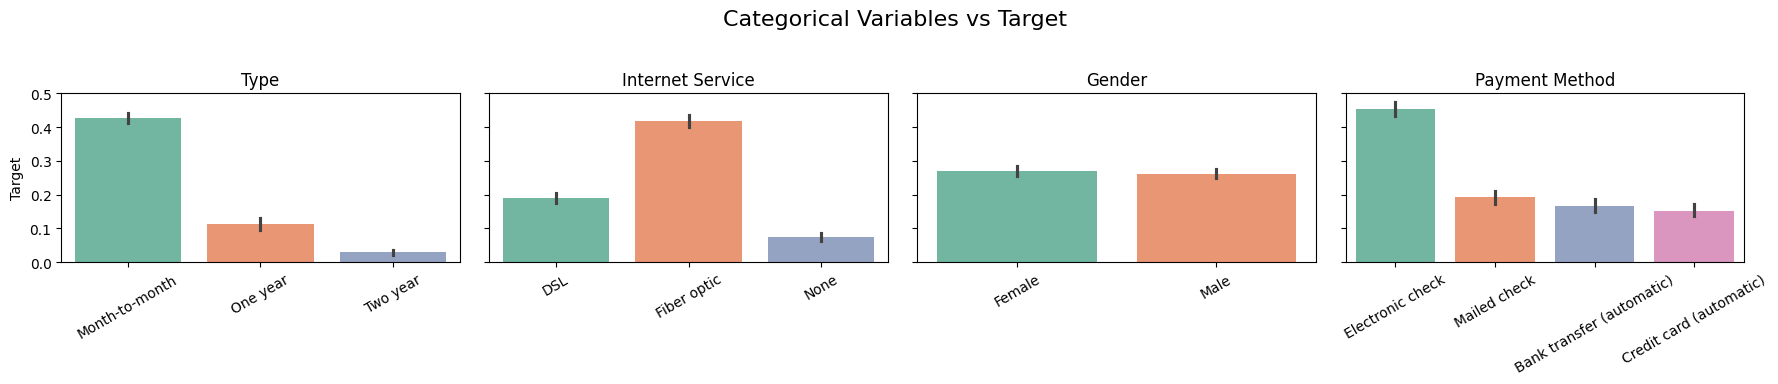

In [49]:
# Define color palettes for each plot based on unique categories
palette_type = sns.color_palette('Set2', n_colors=df['Type'].nunique())
palette_internet = sns.color_palette('Set2', n_colors=df['InternetService'].nunique())
palette_gender = sns.color_palette('Set2', n_colors=df['gender'].nunique())
palette_payment = sns.color_palette('Set2', n_colors=df['PaymentMethod'].nunique())

# Crear subplots
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle('Categorical Variables vs Target', fontsize=16)

sns.barplot(ax=axes[0], data=df, x='Type', y='target', hue='Type', palette=palette_type, legend=False)
axes[0].set_title('Type')

sns.barplot(ax=axes[1], data=df, x='InternetService', y='target', hue='InternetService', palette=palette_internet, legend=False)
axes[1].set_title('Internet Service')

sns.barplot(ax=axes[2], data=df, x='gender', y='target', hue='gender', palette=palette_gender, legend=False)
axes[2].set_title('Gender')

sns.barplot(ax=axes[3], data=df, x='PaymentMethod', y='target', hue='PaymentMethod', palette=palette_payment, legend=False)
axes[3].set_title('Payment Method')

# Rotate x-ticks
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('')
    ax.set_ylabel('Target')

plt.ylim(0, 0.5)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Estas gráficas nos ayudan a que tipo de clientes y/o servicios categoricos tienen la taza mas alta de cancelacion.  

Los clientes con menor taza de cancelacion en **tipo de pago** son los que tienen contrato a dos años, y los que tienen tipo de pago mes con mes son los que tienen la taza mas alta de cancelacion.

En **Internet** los clientes con ***mayor cancelacion*** son lo de fibra optica, seguido de los que usan DSL, finalmente los que no tienen servicio de internet.

En promedio, las mujeres y los hombres cancelan en la misma proporcion el servicio.

La taza mas alta de cancelacion en cuanto al **metodo de pago** son los clientes que pagan con cheque electronico. Los demas todos tienen tazas similares.

## Preguntas

Valdra la pena acortar mis variables categoricas? Por ejemplo sera ams conveniente usar un One Hot Encoder para el tipo de pago, o juntar la categoria de 1 y 2 años? Valdra la pena conservar la columna gender o sera mejor dartle drop?? Actualmente tengo pensado hacer drop de la columna start_date, end_date, customerID, gender. Usar OHE para Internet Service y Type quiza. De resto creo que ya estamos algo listos, haria un pipeline y usaria un standard scaler y OHE dentro de ese pipeline para mis columnas categoricas y mis columnas numericas. Tengo pensado usar una regresion para partir y de resto me gustaria usar un Random Forest y un XGBoost.

# Entrenamiento

## Preparar Datos

Eliminamos primero las columnas que no son relevantes para obtener mi set de features para el entrenamiento.

In [50]:
# Separar características y target
X = df.drop(columns=["customerID","BeginDate","EndDate","gender","target"])
y = df["target"]

## Balanceo de Datos

Para balancear mis datos aplicare tanto oversampling como undersampling, para undersampling aplicare random undersampling y para oversampling aplicare smote. La idea es llevarlos a algo cercano a un 55-45 o 60-40. Utilizare mis mismos pipelines para acelerar todo el proceso de entrenamiento y procesamiento de datos clean.

In [51]:
y.value_counts(normalize=True)

target
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [52]:
y.value_counts()

target
0    5163
1    1869
Name: count, dtype: int64

In [53]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Preprocessing: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Combine everything into a pipeline
resample_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('under', RandomUnderSampler(sampling_strategy=0.7, random_state=42)),
    ('over', SMOTE(sampling_strategy=0.9, random_state=42))
])

X_resampled, y_resampled = resample_pipeline.fit_resample(X, y)

In [54]:
'''
# Aplico mis metodos de undersample y oversample
undersample = RandomUnderSampler(sampling_strategy='auto', random_state=42)  # Reducir clase mayoritaria
X_under, y_under = undersample.fit_resample(X, y)

oversample = SMOTE(sampling_strategy='auto', random_state=42)  # Aumentar clase minoritaria
X_resampled, y_resampled = oversample.fit_resample(X_under, y_under)
'''

"\n# Aplico mis metodos de undersample y oversample\nundersample = RandomUnderSampler(sampling_strategy='auto', random_state=42)  # Reducir clase mayoritaria\nX_under, y_under = undersample.fit_resample(X, y)\n\noversample = SMOTE(sampling_strategy='auto', random_state=42)  # Aumentar clase minoritaria\nX_resampled, y_resampled = oversample.fit_resample(X_under, y_under)\n"

In [55]:
y_resampled.value_counts(normalize=True)

target
0    0.526316
1    0.473684
Name: proportion, dtype: float64

/var/folders/75/n09kg0s137s895fc3yg04jg00000gn/T/ipykernel_19235/1772815914.py:17: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(


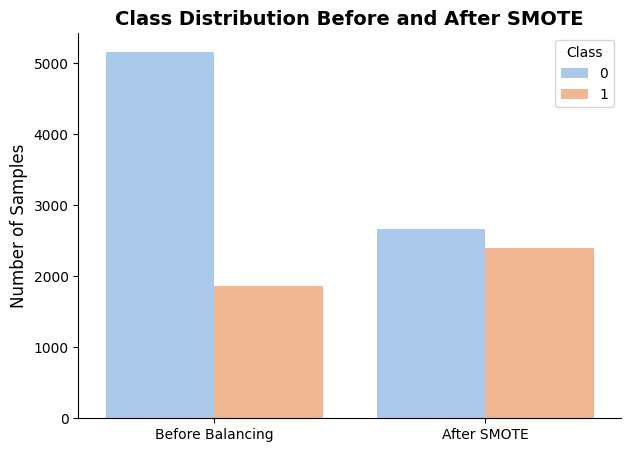

In [56]:
# Count before and after
before_counts = Counter(y)
after_counts = Counter(y_resampled)

# Convert to DataFrame for easier plotting
df_balance = pd.DataFrame({
    'Dataset': ['Before Balancing'] * len(before_counts) + ['After SMOTE'] * len(after_counts),
    'Class': list(before_counts.keys()) + list(after_counts.keys()),
    'Count': list(before_counts.values()) + list(after_counts.values())
})

# Use a soft pastel palette
palette = sns.color_palette('pastel')

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df_balance,
    x='Dataset', 
    y='Count', 
    hue='Class', 
    palette=palette
)

# Titles and labels
plt.title('Class Distribution Before and After SMOTE', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('Number of Samples', fontsize=12)
plt.legend(title='Class', loc='upper right')
sns.despine()

plt.show()

## Train Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

In [58]:
# Funtion to evaluate model
def evaluate_model(model, train_features, train_target, test_features, test_target):
    eval_stats = {}

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig.suptitle('ROC Curve')

    for split, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[split] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # Accuracy
        accuracy = metrics.accuracy_score(target, pred_target)
        eval_stats[split]['Accuracy'] = accuracy

        # ROC AUC
        fpr, tpr, thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[split]['ROC AUC'] = roc_auc

        # Plot ROC
        color = 'blue' if split == 'train' else 'green'
        ax.plot(fpr, tpr, label=f'{split} AUC = {roc_auc:.2f}', color=color)

    ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend(loc='lower right')
    plt.show()

    df_eval_stats = pd.DataFrame(eval_stats).round(2).reindex(index=('Accuracy', 'ROC AUC'))

    return df_eval_stats

### Logistic Regression

In [59]:
# Define feature types
categorical_features = ['Type', 'InternetService', 'PaymentMethod']
numeric_features = ['MonthlyCharges', 'TotalCharges']

# The rest are already numeric and should pass through unchanged
binary_features = [col for col in X_test.columns if col not in categorical_features + numeric_features]

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_features),
    ('num', StandardScaler(), numeric_features),
    ('bin', 'passthrough', binary_features)
])

pipeline_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

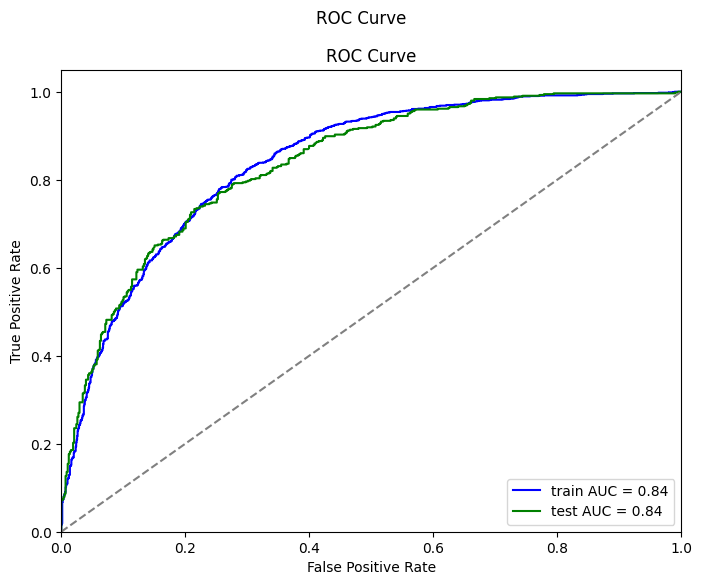

,train,test
Accuracy,0.76,0.76
ROC AUC,0.84,0.84


In [ ]:
# Fit your pipeline on the training data
pipeline_lr.fit(X_train, y_train)
# Evaluate
lr = evaluate_model(pipeline_lr, X_train, y_train, X_test, y_test)
lr

## Random Forest Classifier

Best parameters for Random Forest: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


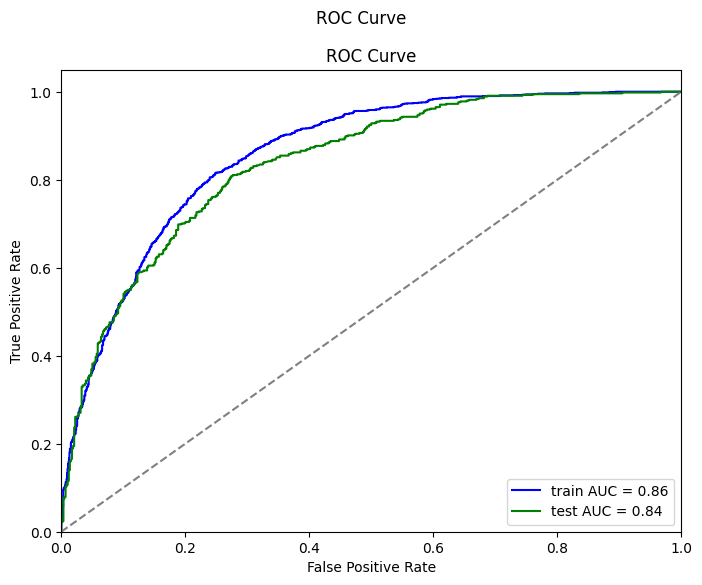

,train,test
Accuracy,0.78,0.76
ROC AUC,0.86,0.84


In [ ]:
pipeline_rf = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid=param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_rf.best_params_)
rf = evaluate_model(grid_rf.best_estimator_, X_train, y_train, X_test, y_test)
rf

## XGBoost

Best parameters for XGBoost: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


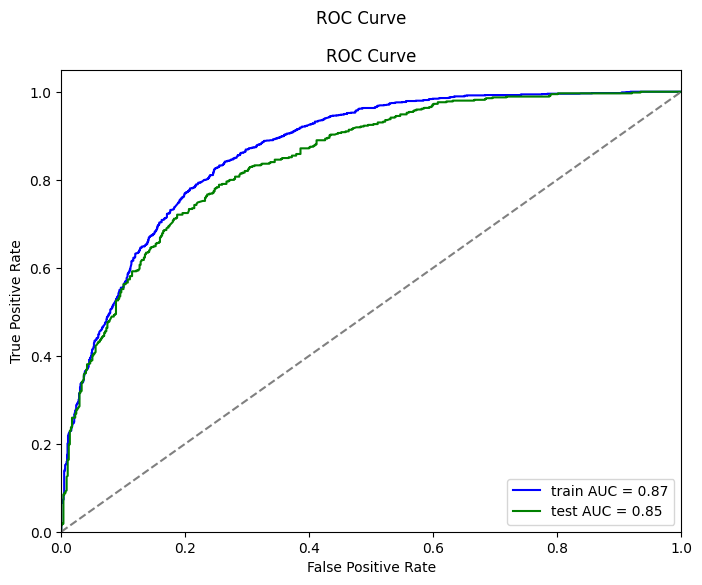

,train,test
Accuracy,0.79,0.76
ROC AUC,0.87,0.85


In [ ]:
pipeline_xgb = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5, 7]
}

grid_xgb = GridSearchCV(pipeline_xgb, param_grid=param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Best parameters for XGBoost:", grid_xgb.best_params_)
xgb = evaluate_model(grid_xgb.best_estimator_, X_train, y_train, X_test, y_test)
xgb

## Conclusiones

In [ ]:
combined_eval = pd.concat(
    [lr.rename(columns={'train': 'LR Train', 'test': 'LR Test'}),
     rf.rename(columns={'train': 'RF Train', 'test': 'RF Test'}),
     xgb.rename(columns={'train': 'XGB Train', 'test': 'XGB Test'})],
    axis=1
)

combined_eval

,LR Train,LR Test,RF Train,RF Test,XGB Train,XGB Test
Accuracy,0.76,0.76,0.78,0.76,0.79,0.76
ROC AUC,0.84,0.84,0.86,0.84,0.87,0.85


Los tres modelos en general tuvieron buenos resultados, y los train/test estan bastante cercanos los unos a los otros, lo cual me hace ver que no tenemos **overfitting**.

- **XGBoost** dio el mejor performance con un ROC AUC de 0.87 en train y 0.85 en test. Esto se traduce a que evalua mejor los usuarios que se quedan y que se pueden ir ligeramente mejor que los otros dos modelos.
- **Logistic Regression** dio un buen performance y nos sirve como punto medio para evaluar.
- **Random Forest Classifier** es un buen punto medio, pero en esta ocasion sera mas conveniente utilizar XGBoost.

# Informe de Solución | Predicción de Abandono de cliente

**Objetivo:**  
El objetivo principal de este proyecto fue construir un modelo predictivo que identifique a los usuarios con mayor probabilidad de cancelar el servicio (**churn**).

---

## Pasos Realizados

### Exploración y Preprocesamiento de Datos
- Se trabajó con un conjunto de datos de **7,043 usuarios**, con información sobre:
  - Tipo de contrato
  - Servicios contratados (Internet, Soporte técnico, Streaming, etc.)
  - Método de pago, facturación electrónica
  - Cargos mensuales y totales
  - Información demográfica (pareja, dependientes, tercera edad, etc.)

- Se eliminaron columnas no útiles para el modelo:
  - `customerID`, `StartDate`, `EndDate` y `gender`.

- Se manejaron valores faltantes:
  - Se detectaron filas con espacios en blanco en `TotalCharges` y se eliminaron antes de convertir a tipo numérico.

---

### Ingeniería de Características
- Se utilizó **One-Hot Encoding** para variables categóricas como:
  - `Type`, `PaymentMethod`, `InternetService`.
  
- Se aplicó **StandardScaler** a las variables numéricas:
  - `MonthlyCharges`, `TotalCharges`.

- Las variables binarias (`Yes` / `No`) fueron transformadas a **1** y **0**.

---

### Manejo del Desbalance de Clases
- La variable objetivo (`churn`) estaba desbalanceada:  
  - ~73% usuarios activos (clase 0)  
  - ~26% usuarios que cancelaron (clase 1)

- Se aplicó una combinación de:
  - **Submuestreo aleatorio (RandomUnderSampler)**
  - **SMOTE** (Oversampling de la clase minoritaria)

---

### Entrenamiento de Modelos
Se entrenaron y evaluaron tres modelos utilizando **pipelines** con `ColumnTransformer`:

1. **Regresión Logística** (modelo base)
2. **Random Forest**
3. **XGBoost**

- Se usó **GridSearchCV** para la búsqueda de hiperparámetros.
- Se aplicó **cross-validation** para una evaluación más robusta.

---

## Evaluación del Modelo

Métricas utilizadas:
- **Accuracy**
- **ROC AUC** (principal métrica, debido al desbalance de clases)

Evaluación de los modelos:

| Modelo               | ROC AUC Entrenamiento | ROC AUC Prueba |
|----------------------|-----------------------|----------------|
| Regresión Logística  | 0.84                  | 0.84           |
| Random Forest        | 0.86                  | 0.84           |
| **XGBoost (final)**  | **0.87**              | **0.85**       |

---

## Pasos Omitidos

- No se usaron modelos de deep learning por la naturaleza estructurada de los datos y el buen rendimiento de los métodos actuales.
- No se implementó selección de características (SHAP, mutual information) por razones de tiempo. Sería útil en un entorno de producción.

---

## Dificultades y Soluciones

- **Desbalance de clases:**  
  Inicialmente afectó el rendimiento. Se resolvió con undersampling + SMOTE.

- **Overfitting con XGBoost sin OHE:**  
  XGBoost sobreajustaba cuando se entrenaba con categorías codificadas como texto. Se corrigió utilizando **OHE**, que dio mejores resultados.

- **Consistencia de Preprocesamiento:**  
  Se garantizó el uso de pipelines para evitar fugas de datos y mantener un flujo reproducible.

---

## Conclusión

- Los tres modelos dieron buenos resultados y mostraron consistencia entre los conjuntos de entrenamiento y prueba.
- **No hubo signos de sobreajuste.**
- El modelo final seleccionado fue **XGBoost**, por obtener la mejor puntuación ROC AUC (0.87 en entrenamiento, 0.85 en prueba).
- Este modelo es el más adecuado para predecir con precisión qué usuarios tienen mayor probabilidad de cancelar el servicio.